<center><h1><u>Assignment:10- Convolution and CNN for Time Series</center></h1></u>

Hello everyone!! A hearty welcome to the 10th Assignment of the time series module.

![](https://i.pinimg.com/originals/68/fc/84/68fc840dc98e026ba8c76fdfc5e82855.jpg)

In this assignment you will be learning about Convolution in Time series with its simulation and CNN for time series.

<h2><u>Table of Contents:</h2></u>

1. Convolutional Neural Networks<br>
2. Effect of Convolution on numerical data<br>
3. CNN for Time Series forecasting

<h1><u>Convolutional Neural Networks</h1></u>

A Convolutional Neural Network (ConvNet/CNN) is a Deep Learning system that can take an input image, assign relevance (learnable weights and biases) to various aspects/objects in the image, and distinguish between them. The architecture of a ConvNet is inspired by the organisation of the Visual Cortex and is akin to the connectivity pattern of Neurons in the Human Brain. Individual neurons can only respond to stimuli in a small area of the visual field called the Receptive Field. A number of similar fields can be stacked on top of each other to span the full visual field.

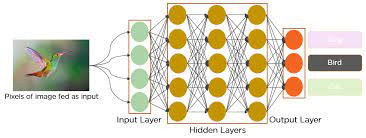

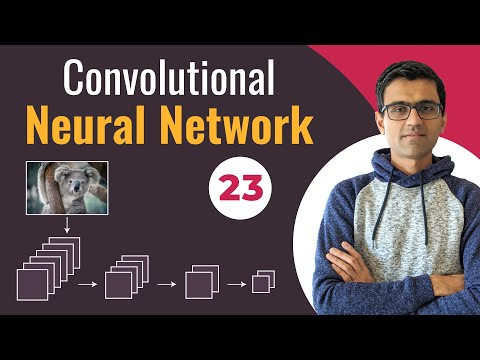

In [ ]:
###Refer Video
from IPython.display import YouTubeVideo
YouTubeVideo('zfiSAzpy9NM', width=700, height=400)

<h3><u>Architecture of CNN</h3></u>

![](https://boostedml.com/wp-content/uploads/2020/04/image-4.png)

The convolutional layer receives a fixed length sub-sequence of the complete time series from the input layer. The input is smoothed by the convolutional and pooling layers, which we will discuss shortly. The RELU layer applies a RELU non-linear transformation to the smoothed sub-sequence, and the output plugs the vector-valued result into another activation function to produce class probabilities, a continuous-valued response, counts, or any other type of response depending on the activation function used.

<h3><u>Convolutional Layers</h3></u>

* **What is a Convolution?**

Convolution, in purely mathematical terms, is a function formed by integration from two given functions that expresses how the shape of one is modified by the other.

![](https://www.researchgate.net/profile/Volker-Weinberg/publication/332190148/figure/fig2/AS:743933420249088@1554378957080/Schematic-illustration-of-a-convolutional-operation-The-convolutional-kernel-shifts-over.ppm)

At its core, 2D convolution is a rather straightforward operation: you begin with a kernel, which is simply a small matrix of weights. This kernel "slides" over the 2D input data, doing elementwise multiplication with the portion of the input it is currently on, and summing the results into a single output pixel. For each point it glides over, the kernel repeats the process, transforming a 2D matrix of features into another 2D matrix of features. The output features are essentially the weighted sums of the input features positioned nearly in the same location as the output pixel on the input layer (with the weights being the kernel's own values).

* Refer: https://towardsdatascience.com/intuitively-understanding-convolutions-for-deep-learning-1f6f42faee1

A convolution matrix can be used to alter an image. Here are a few examples of picture filters created with these matrices.

![](https://sds-platform-private.s3-us-east-2.amazonaws.com/uploads/70_blog_image_6.png)
![](https://sds-platform-private.s3-us-east-2.amazonaws.com/uploads/70_blog_image_7.png)

<h3><u>Pooling</h3></u>

Pooling involves chunking a vector into non-overlapping equal sized groups or ‘pools’, and then taking a summary statistic for each group. This further smooths out noise in local dynamics. Three common types of pool are max pooling (very common with images), average or mean pooling, and min pooling.

![](https://miro.medium.com/max/500/1*KQIEqhxzICU7thjaQBfPBQ.png)

<h3><u>RELU Layer</h3></u>

The relu layer takes the smoothed vector obtained from the convolutional and pooling layers and applies non-linearity to it in order to prepare it for the final output layer.

![](https://sds-platform-private.s3-us-east-2.amazonaws.com/uploads/71_blog_image_1.png)

<h3><u>Output Layer</h3></u>

The final output layer takes a representation of our original data that has gone through two layers of smoothing and one layer of non-linear transformation, and applies an activation function to a weighted sum of that representation to produce output data that is of the relevant form based on our activation function of choice. Class probabilities, a continuous-valued response, count data, or ordinal data are all examples of this.

<h1><b>For deep intuition of Convolutional neural networks, refer the given documentation:</h1></b>

https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53

<h1><u>Effect of Convolution on numerical data</h1></u>

We know the effect of Convolution on images like applying various filters,edge detection,etc.

![](https://miro.medium.com/max/1206/1*ZPXWZDIHFbTxs-6KVPS5gg.png)

In this section we will see how convolution affects numerical data and time series. Here we simulate a sequence, applying a convolution to that sequence, and then apply average pooling to get some intuition for how these layers change our original data.



Lets start by importing the required libraries.
* numpy: for array and matrix operations
* skimage.measure
* matplotlib: for visualizations



In [1]:
#import the above mentioned libraries
# numerical operations
import numpy as np

# pooling operations
from skimage.measure import block_reduce

# visualization
import matplotlib.pyplot as plt

Now you need to create a sequence of numbers on which convolution will be performed. Use the np.random.normal function to do so. random.normal draws random samples from a normal (Gaussian) distribution. Take mean as 0 and standard deviation as 10 and size as 100.

* Refer: https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html.

After creating the sequence take the cumulative sum of the sequence using cumsum method.
* Refer: https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html.

Initialize an array that will be used as kernel([1,1,2,5,3])for convolution. Use the convolve function of numpy to convolve the cumulative sequence and the defined kernel. Keep mode as 'same' which returns the convolved array with same size as that of the maximum of two passed arrays.
* Refer: https://numpy.org/doc/stable/reference/generated/numpy.convolve.html.

Take the transpose of the convolved array using np.matrix.T.
* Refer: https://numpy.org/doc/stable/reference/generated/numpy.matrix.T.html


In [2]:
# create random noisy data
np.random.seed(10)

sequence = np.random.normal(
    loc=0,      # mean
    scale=10,   # standard deviation
    size=100    # total samples
)

print(sequence[:10])
# cumulative sum
cumulated_sequence = np.cumsum(sequence)

print(cumulated_sequence[:10])
# convolution kernel
kernel = np.array([1,1,2,5,3])

print(kernel)
# apply convolution
convolved = np.convolve(
    cumulated_sequence,
    kernel,
    mode='same'
)

print(convolved[:10])
# convert to matrix and transpose
convolved_transpose = np.matrix(convolved).T

print(convolved_transpose[:5])


[ 13.31586504   7.15278974 -15.45400292  -0.0838385    6.21335974
  -7.20085561   2.65511586   1.08548526   0.04291431  -1.74600211]
[13.31586504 20.46865479  5.01465186  4.93081336 11.1441731   3.9433175
  6.59843335  7.68391861  7.72683292  5.98083081]
[1 1 2 5 3]
[ 52.11503673 117.46210001 168.39515925 111.42834101  72.52811947
  92.68229257  81.75672503  73.89762021  89.96048248 106.30014123]
[[ 52.11503673]
 [117.46210001]
 [168.39515925]
 [111.42834101]
 [ 72.52811947]]


\The seqeunce and convolved sequence both are ready. lets first visualize the original sequence using matplotlib.

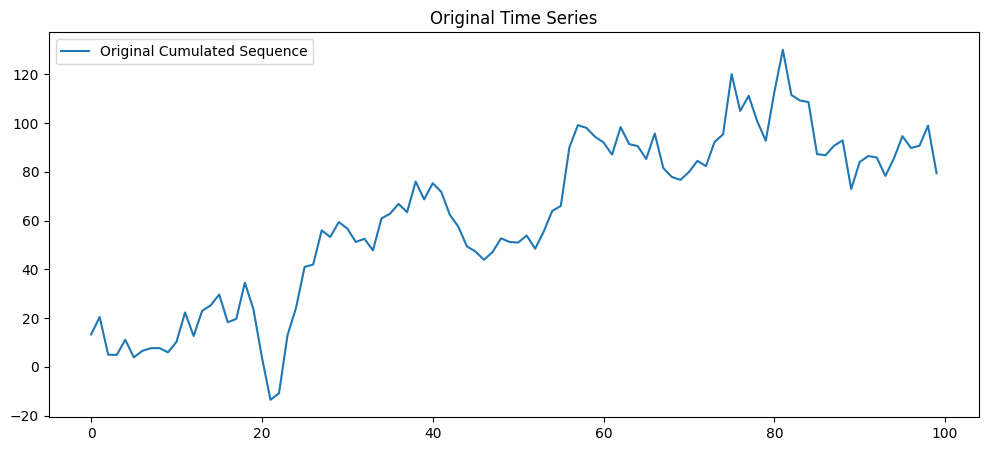

In [3]:
# plot original sequence
plt.figure(figsize=(12,5))

plt.plot(
    cumulated_sequence,
    label='Original Cumulated Sequence'
)

plt.legend()

plt.title('Original Time Series')

plt.show()

Next visualize the convolved sequence.

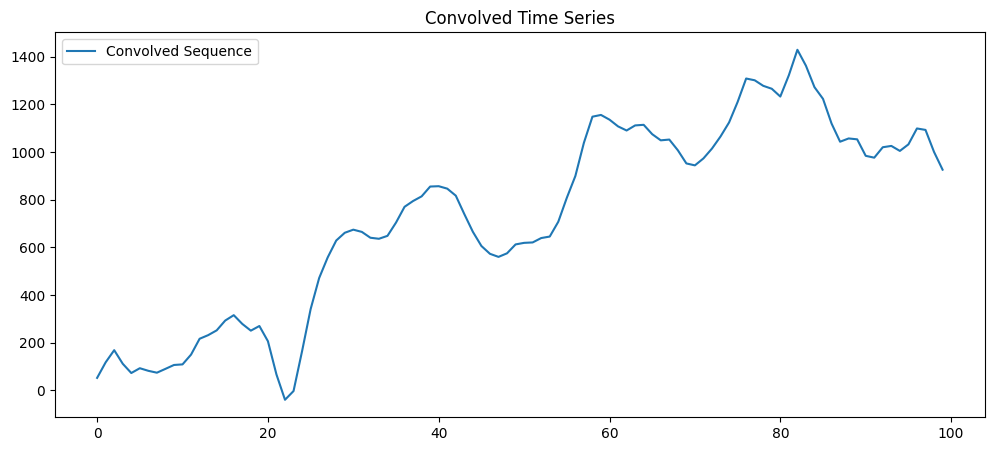

In [4]:
# plot convolved sequence
plt.figure(figsize=(12,5))

plt.plot(
    convolved,
    label='Convolved Sequence'
)

plt.legend()

plt.title('Convolved Time Series')

plt.show()

As you can see, a lot of the noise has been smoothed out, and the plot now looks much less jagged.

We then apply average pooling with pools of size 3. For this use the skimage.measure.block_reduce function which downsamples  or data by applying function to local blocks. The function used in this case will be np.mean as we are performing average pooling.
* Refer: https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.block_reduce

[112.657432    92.21291768  81.87160924 121.62816829 233.0561935
 295.49582534 242.03488358   7.86067969 325.33084023 615.72440372]


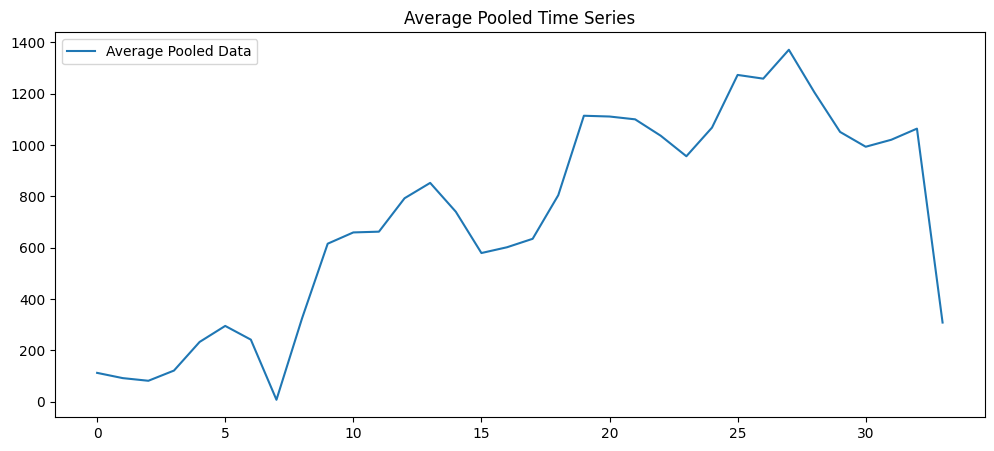

In [5]:
# apply average pooling
pooled_data = block_reduce(
    convolved,
    block_size=3,
    func=np.mean
)

print(pooled_data[:10])
plt.figure(figsize=(12,5))

plt.plot(
    pooled_data,
    label='Average Pooled Data'
)

plt.legend()

plt.title('Average Pooled Time Series')

plt.show()


This time it's a lot smoother. <br>
Hence convolution smoothes the data and removes extra noise in case of time series data as well.

<h1><u>CNN for Time Series forecasting</h1></u>


After seeing the effect of convolution on time series data, we now look at how CNN is useful in time series forecasting.

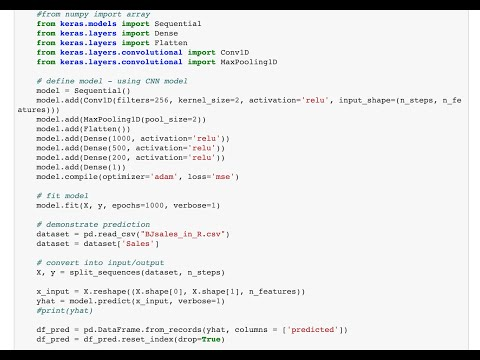

In [ ]:
## Refer video
YouTubeVideo('1AzwQDmUfCA', width=700, height=400)

The dataset used in the project is present in the google drive. So the drive has to be first mounted to use the dataset. For that use the drive library from google.colab and then mount the drive using mount function.

In [ ]:
# import drive from google.colab

# mount the drive


Mounted at /content/drive


Next import the necessary libraries.
* warnings: to work on arising warnings during execution.
* numpy: for array and matrix operations
* matplotlib.pyplot: for plotting and visualizations
* pandas: for storing and manipulating data
* statsmodels.api: classes and functions for statistical models
* plot_acf: for plotting autocorrelation plot

In [6]:
#import above mentioned libararies

#filter warnings to ignore them
import warnings

import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf
warnings.filterwarnings('ignore')

Now you need to set some of the matplotlib parameters so that you dont need to specify them everytime. use the rcParams function to do so. You need to pass the parameter name and its corresponding value.
* Refer: https://matplotlib.org/stable/api/matplotlib_configuration_api.html

In [7]:
plt.rcParams['axes.labelsize'] = 14

plt.rcParams['xtick.labelsize'] = 12

plt.rcParams['ytick.labelsize'] = 12

plt.rcParams['text.color'] = 'black'

plt.rcParams['figure.figsize'] = (12,5)

Ahead read the dataset using read_csv method. Download the dataset from the given link and upload it in your drive. https://drive.google.com/file/d/1atMdurgvBBZGtK1XmD0X7zqByHxQi-M8/view?usp=sharing. <br>Parse the dates and keep index column as 0th column when reading the csv. The dataset contains two columns,time and sales. Plot the dataset using matplotlib.pyplot

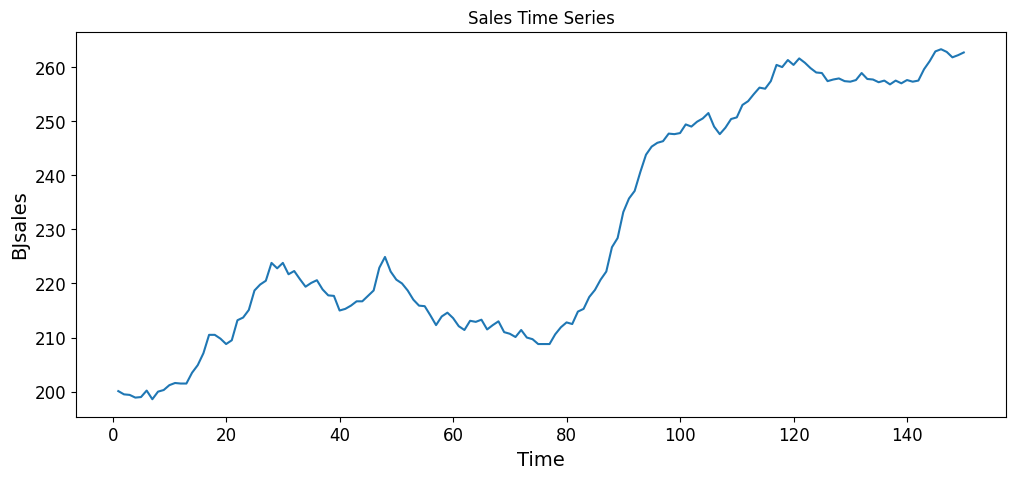

In [9]:
#get dataset path
path='/content/BJ_Sales.csv'
#read the dataset
dataset=pd.read_csv(path)
dataset.set_index('time',inplace=True)
#plot the data
plt.plot(dataset['BJsales'])

plt.title('Sales Time Series')

plt.xlabel('Time')

plt.ylabel('BJsales')

plt.show()

After reading the dataset,check its shape and first 5 or 10 rows using head function.

In [11]:
#print dataset shape
print(dataset.shape)
#print first 5 or 10 rows
dataset.head()

(150, 1)


,BJsales
time,
1,200.1
2,199.5
3,199.4
4,198.9
5,199.0


Next check the autocorrelation plot using plot_acf

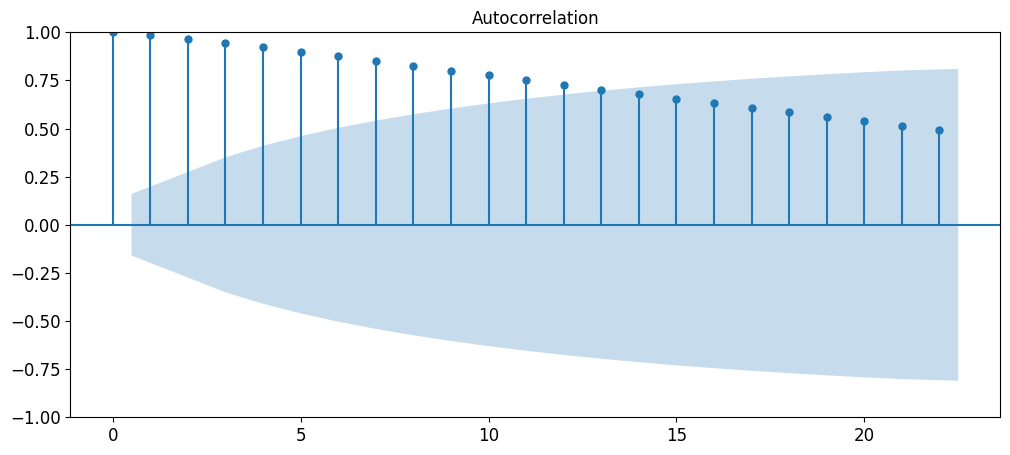

In [12]:
#plot_acf
plot_acf(dataset['BJsales'])

plt.show()


The values are quite correlated.<br>
Next in, create a function which will split the sequences in given number of steps. For example, consider a sequence [1,2,3,4,5,6] and number of steps as 3. Our function will return numerous sequences like X=([1,2,3],[2,3,4],[3,4,5],[4,5,6]) and y=[3,4,5,6].Hence the original sequence is divided based on number of steps and the last number in each step is the output(base for next prediction).

**This function is implemented as in time series each value or observation is highly dependent on previous observation.**

In [13]:
from numpy import array

def split_sequence(sequence, n_steps):

    X = []
    y = []

    for i in range(len(sequence)):

        end_ix = i + n_steps

        if end_ix >= len(sequence):
            break

        seq_x = sequence[i:end_ix]

        seq_y = sequence[end_ix]

        X.append(seq_x)

        y.append(seq_y)

    return array(X), array(y)

Next apply the above created function by passing the dataset and number of steps as 3. Print the X and y data to understand that how the data has been splitted.

In [15]:
n_steps = 3

X, y = split_sequence(
    dataset['BJsales'].values,
    n_steps
)

print(X.shape)

print(X[:5])

print(y[:5])

(147, 3)
[[200.1 199.5 199.4]
 [199.5 199.4 198.9]
 [199.4 198.9 199. ]
 [198.9 199.  200.2]
 [199.  200.2 198.6]]
[198.9 199.  200.2 198.6 200. ]


Reshape the X data based on number of features which is 1. reshape from [samples, timesteps] into [samples, timesteps, number of features]

In [16]:
n_features = 1

X = X.reshape(
    (X.shape[0], X.shape[1], n_features)
)

print(X.shape)

(147, 3, 1)


The data has now been processed. Its time for creating the model. Before beginning import some necessary dependencies.
* Sequential: groups a linear stack of layers into a tf.keras.Model.
* Dense, Flatten, Conv2D, MaxPool2D

Refer:
* https://keras.io/api/layers/core_layers/dense/
* https://keras.io/api/layers/reshaping_layers/flatten/
* https://keras.io/api/layers/convolution_layers/convolution2d/
* https://keras.io/api/layers/pooling_layers/max_pooling2d

In [17]:
#import above mentioned dependencies
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense
)

# create model
model = Sequential()

# convolution layer
model.add(
    Conv1D(
        filters=256,
        kernel_size=2,
        activation='relu',
        input_shape=(n_steps, n_features)
    )
)

# max pooling layer
model.add(
    MaxPooling1D(
        pool_size=2
    )
)

# flatten layer
model.add(Flatten())

# dense layers
model.add(Dense(1000, activation='relu'))

model.add(Dense(500, activation='relu'))

model.add(Dense(200, activation='relu'))

# output layer
model.add(Dense(1))

# model summary
model.summary()
#compile model using adam optimizer and mse loss function

model.compile(
    optimizer='adam',
    loss='mse'
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2, 256)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       257,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,669 (3.28 MB)

 Trainable params: 858,669 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

After creating the model, fit the model using fit() function and 500 epochs

In [18]:
# fit model
model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 19896.5000
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4036.6147
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2617.4485
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 689.2332
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 345.6006
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 400.3898
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 191.5645
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 64.9963
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 45.1909
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 29.7171
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 24.7995
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 18.7821
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.0228
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 6.6948
Epoch 15/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.

Lets now predict the data using the predict function.

In [19]:
#predict X
yhat = model.predict(X)

print(yhat[:10])
#print(yhat)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[199.93454]
 [199.56628]
 [199.30634]
 [199.72964]
 [200.09265]
 [199.9627 ]
 [200.28789]
 [200.84354]
 [201.4975 ]
 [201.68869]]


Store these predictions in another dataframe using the pd.DataFrame function.
* Refer: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.from_records.html

In [20]:
df_pred = pd.DataFrame.from_records(
    yhat,
    columns=['Predicted']
)

df_pred = df_pred.reset_index(drop=True)

df_actual = dataset[n_steps:len(dataset)]

df_actual = df_actual.reset_index(drop=True)

Our next task is to evaluate the performance of the model. Import the below mentioned metrics from sklearn.metrics.
* r2_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
* mean_absolute_error: http://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
* mean_squared error: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
* mean_squared_log_error: http://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_log_error.html

Apply these metrics to the actual data and predicted data and print it.

In [21]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
# R2 score
r2 = r2_score(y, yhat)

print("R2 Score:", r2)

# MAE
mae = mean_absolute_error(y, yhat)

print("Mean Absolute Error:", mae)

# MSE
mse = mean_squared_error(y, yhat)

print("Mean Squared Error:", mse)

# MSLE
msle = mean_squared_log_error(
    np.abs(y)+1,
    np.abs(yhat)+1
)

print("Mean Squared Log Error:", msle)

# RMSE
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

R2 Score: 0.9902383812094409
Mean Absolute Error: 1.6710594125345444
Mean Squared Error: 4.378271186171464
Mean Squared Log Error: 8.467437052534846e-05
Root Mean Squared Error: 2.0924318832811415


The performance of our model looks good!!<br>
Better understand this performance by plotting the observed and predicted data.

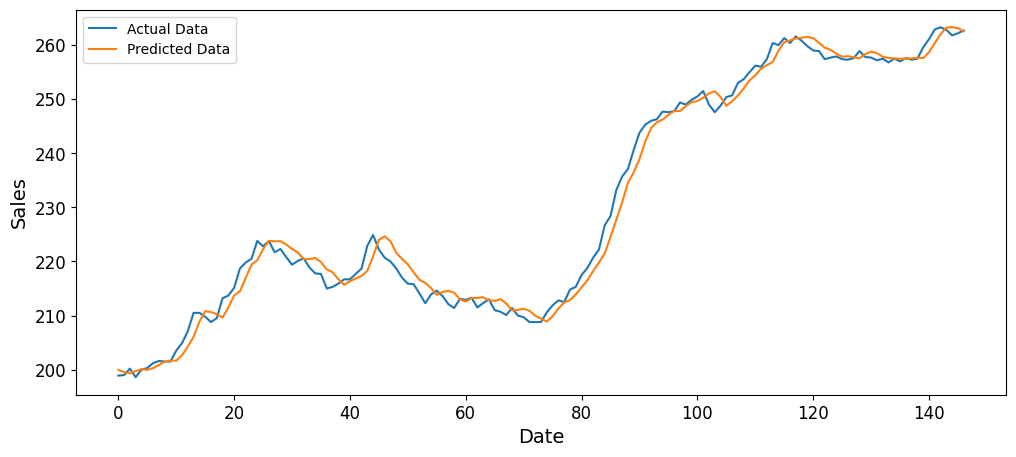

In [23]:
plt.figure(figsize=(12,5))

plt.plot(
    df_actual['BJsales'],
    label='Actual Data'
)

plt.plot(
    df_pred['Predicted'],
    label='Predicted Data'
)

plt.xlabel('Date')

plt.ylabel('Sales')

plt.legend()

plt.show()

### The plot seems very nice!!

Next lets forecast the data. For this we need to apply some processing to craeted the forecasted data as no function is present in CNN for forecasting.

In [24]:
predictions = []

future_time_steps = 7

x1 = X[-1:,:,:]

p1 = yhat[-1:]

for i in range(future_time_steps):

    x2 = np.array([
        [
            x1[0][1][0],
            x1[0][2][0],
            p1[0][0]
        ]
    ]).astype('float32')

    x2 = x2.reshape((1, n_steps, n_features))

    p2 = model.predict(x2)

    predictions.append(p2[0][0])

    x1 = x2

    p1 = p2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


Now start by iterating through range of future time steps and create a new array by passing 1st index value of 0th data value,2nd index value of 0th data value and p1(last prediction). Then predict this newly formed array and append in predictions. Follow this process in each iteration.

In [25]:
yhat_future = np.array(predictions)

yhat_future = yhat_future.reshape(-1,1)

df_future = pd.DataFrame(
    yhat_future,
    columns=['Forecast']
)

print(df_future)

     Forecast
0  262.437500
1  262.609741
2  262.632416
3  262.703583
4  262.743042
5  262.797882
6  262.843964


After getting the forecasted data,lets plot the data.

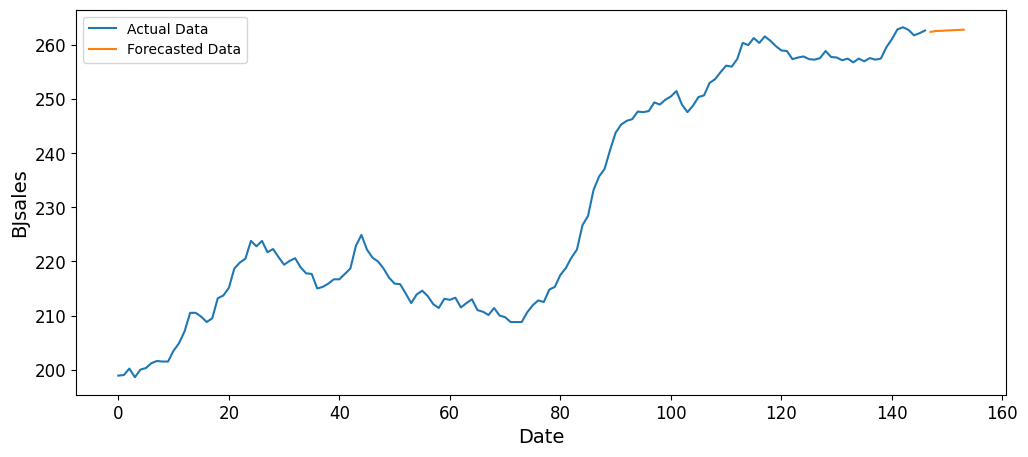

In [26]:
plt.figure(figsize=(12,5))

plt.plot(
    df_actual['BJsales'],
    label='Actual Data'
)

future_x = np.arange(
    len(df_actual),
    len(df_actual)+future_time_steps
)

plt.plot(
    future_x,
    df_future['Forecast'],
    label='Forecasted Data'
)

plt.xlabel('Date')

plt.ylabel('BJsales')

plt.legend()

plt.show()

Congratulations!!! You've done it.

In this assignment you learned:
* CNN
* Effect of convolution on time series data
* Using CNN to forecast time series


Keep practising!!<br><br>

## Do fill the feedback form given below:
[Feedback form](https://forms.zohopublic.in/cloudyml/form/CloudyMLDeepLearningFeedbackForm/formperma/VCFbldnXAnbcgAIl0lWv2blgHdSldheO4RfktMdgK7)
<br><br> See you then!!

![](https://media.makeameme.org/created/ok-bye-now.jpg)
